#  AI User Behavior & Marketing Intelligence Assistant

Turn data about how people use AI assistants into trusted marketing insights.

```text
Understanding AI Users → Identifying Target Audiences → Discovering Marketing Opportunities → Generating Marketing Insights
```

### Pipeline

```text
Choose a Problem
      ↓
Get a Dataset
      ↓
Load Data with Spark
      ↓
Data Quality Checks
      ↓
Quality Gate
   ↙       ↘
 FAIL      PASS
  ↓          ↓
Rejected    Delta Lake
               ↓
        Clean/Trusted Data
               ↓
         AI / RAG + Analytics
```

## 0. Setup

In [1]:
%pip install -q pyspark==3.5.3 delta-spark==3.2.1 loguru pyarrow sentence-transformers chromadb openai python-dotenv matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 7.8 MB/s eta 0:00:00
   ━━━━

In [2]:
import os
DATASET_NAME = "Daily_AI_Assistant_Usage_Behavior_Dataset.csv"
if not any(os.path.exists(p) for p in [f"data/raw/{DATASET_NAME}", DATASET_NAME]):
    from google.colab import files
    files.upload()
print("Dataset found:", [p for p in [f"data/raw/{DATASET_NAME}", DATASET_NAME] if os.path.exists(p)])

Dataset found: ['Daily_AI_Assistant_Usage_Behavior_Dataset.csv']


In [3]:
import os, sys, json, shutil, re, time, getpass
from datetime import datetime
from functools import reduce

import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from delta import configure_spark_with_delta_pip
from delta.tables import DeltaTable

# Folders
SOURCE_FILE    = next(p for p in [f"data/raw/{DATASET_NAME}", DATASET_NAME] if os.path.exists(p))
LANDING_ZONE   = "data/landing_zone"
VALIDATED_PATH = "data/delta/validated_sessions"
TRUSTED_PATH   = "data/delta/trusted_sessions"
PROFILES_PATH  = "data/delta/segment_profiles"
CHROMA_PATH    = "data/chroma_db"
OUTPUTS        = "outputs"

# Start clean so the notebook can be re-run from top to bottom.
for folder in [LANDING_ZONE, "data/delta", CHROMA_PATH, OUTPUTS, "logs"]:
    shutil.rmtree(folder, ignore_errors=True)
for folder in [LANDING_ZONE, OUTPUTS, "logs"]:
    os.makedirs(folder, exist_ok=True)

# Logging
LOG_FORMAT = "{time:YYYY-MM-DD HH:mm:ss} | {level} | {message}"
logger.remove()
logger.add(sys.stdout, format=LOG_FORMAT, level="INFO")
logger.add("logs/pipeline_execution.log", format=LOG_FORMAT, level="INFO")

# Spark + Delta Lake
builder = (
    SparkSession.builder
    .appName("AIUserBehaviorMarketingIntelligence")
    .master("local[*]")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "4")
)
spark = configure_spark_with_delta_pip(builder).getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("🚀 Spark", spark.version, "+ Delta Lake ready | dataset:", SOURCE_FILE)

🚀 Spark 3.5.3 + Delta Lake ready | dataset: Daily_AI_Assistant_Usage_Behavior_Dataset.csv


## 1. Choose a Problem

| | |
|---|---|
| **Problem** | Marketing teams of AI products do not know *who* uses AI assistants, *for what*, *on which device and model*, *for how long* and *how satisfied* they are — so targeting and messaging are guesswork. |
| **Data needed** | Session logs of AI-assistant usage: time, device, usage category, prompt length, session length, satisfaction, AI model, tokens used. |
| **Expected output** | A trusted Delta Lake table protected by a quality gate, segment profiles, and an AI assistant (RAG) that answers marketing questions using only the data. |

**Questions the assistant must answer**
1. What are the most common ways people use AI assistants?
2. What are the characteristics of users who frequently use AI for coding?
3. How do Coding users differ from Education or Writing users?
4. What type of AI users could be relevant for a specific AI product?
5. What user behaviors indicate high engagement with AI?
6. What marketing opportunities can be identified from AI usage patterns?
7. What type of marketing message could be relevant to a specific user segment?

> The dataset has no user ID — each row is one **session**, so segments describe usage behavior.

## 2. Get a Dataset

**Daily AI Assistant Usage Behavior Dataset** — 300 AI-assistant sessions (Jan–Mar 2025).

| Column | Meaning |
|---|---|
| `timestamp` | session start (`yyyy-MM-dd HH:mm:ss`) |
| `device` | Desktop, Mobile, Tablet, Smart Speaker |
| `usage_category` | Coding, Education, Writing, Research, Productivity, Entertainment, Daily Tasks |
| `prompt_length` | prompt length (characters) |
| `session_length_minutes` | session duration |
| `satisfaction_rating` | 1 – 5 |
| `assistant_model` | GPT-4o, GPT-5, GPT-5.1, Mini, o1 |
| `tokens_used` | tokens consumed |

Two batches arrive in the landing zone:
- **Batch 1** — the historical dataset (expected to **PASS**).
- **Batch 2** — a new batch of sessions from the apps that contains data errors (expected to **FAIL**).

In [4]:
RAW_COLUMNS = ["timestamp", "device", "usage_category", "prompt_length",
               "session_length_minutes", "satisfaction_rating", "assistant_model", "tokens_used"]

VALID_DEVICES    = ["Desktop", "Mobile", "Tablet", "Smart Speaker"]
VALID_CATEGORIES = ["Coding", "Education", "Writing", "Research", "Productivity", "Entertainment", "Daily Tasks"]
VALID_MODELS     = ["GPT-4o", "GPT-5", "GPT-5.1", "Mini", "o1"]

# Batch 1: the historical dataset lands in the landing zone.
BATCH_1 = f"{LANDING_ZONE}/batch_001_historical.csv"
shutil.copy(SOURCE_FILE, BATCH_1)
logger.info(f"New batch landed: {BATCH_1}")

# Batch 2: new sessions from the apps, with intentional quality problems.
new_sessions = pd.DataFrame([
    ["2025-03-12 08:15:00", "Desktop",       "Coding",       120, 11.20, 5, "GPT-5.1", 1250],
    ["2025-03-12 09:40:00", "Mobile",        "Education",     85,  6.40, 4, "GPT-4o",   640],
    ["2025-03-12 10:05:00", None,            "Writing",      150,  8.10, 3, "GPT-5",    900],   # Completeness: missing device
    ["2025-03-12 11:30:00", "Tablet",        "Research",     200, -4.00, 4, "o1",       700],   # Accuracy: negative session length
    ["2025-03-12 12:10:00", "Desktop",       "Productivity",  60,  5.50, 9, "Mini",     310],   # Accuracy: rating out of 1-5
    ["2025-03-12 13:45:00", "Smart Watch",   "Entertainment", 40,  2.30, 2, "GPT-4o",   150],   # Validity: unknown device
    ["12/03/2025 14:20",    "Mobile",        "Daily Tasks",   30,  1.80, 3, "Mini",     120],   # Validity: wrong timestamp format
    ["2025-03-12 08:15:00", "Desktop",       "Coding",       120, 11.20, 5, "GPT-5.1", 1250],   # Uniqueness: duplicate session
], columns=RAW_COLUMNS)

BATCH_2 = f"{LANDING_ZONE}/batch_002_new_sessions.csv"
new_sessions.to_csv(BATCH_2, index=False)
logger.info(f"New batch landed: {BATCH_2}")

2026-09-30 18:07:24 | INFO | New batch landed: data/landing_zone/batch_001_historical.csv
2026-09-30 18:07:24 | INFO | New batch landed: data/landing_zone/batch_002_new_sessions.csv


## 3. Load Data with Spark

Data is read with an **explicit schema** (Spark does not guess the types). Each row receives:
- `session_id` — a fingerprint of the record (used by the uniqueness check),
- `batch_id` and `ingested_at` — lineage.

In [5]:
RAW_SCHEMA = StructType([
    StructField("timestamp",              StringType(),  True),
    StructField("device",                 StringType(),  True),
    StructField("usage_category",         StringType(),  True),
    StructField("prompt_length",          IntegerType(), True),
    StructField("session_length_minutes", DoubleType(),  True),
    StructField("satisfaction_rating",    IntegerType(), True),
    StructField("assistant_model",        StringType(),  True),
    StructField("tokens_used",            IntegerType(), True),
])
TABLE_COLUMNS = ["session_id"] + RAW_COLUMNS + ["batch_id", "ingested_at"]


def load_batch(path, batch_id):
    df = spark.read.option("header", True).schema(RAW_SCHEMA).csv(path)
    fingerprint = F.concat_ws("|", *[F.coalesce(F.col(c).cast("string"), F.lit("<NULL>")) for c in RAW_COLUMNS])
    return (df.withColumn("session_id", F.substring(F.sha2(fingerprint, 256), 1, 16))
              .withColumn("batch_id", F.lit(batch_id))
              .withColumn("ingested_at", F.current_timestamp())
              .select(TABLE_COLUMNS))


df_batch_1 = load_batch(BATCH_1, "batch_001_historical").cache()
df_batch_2 = load_batch(BATCH_2, "batch_002_new_sessions").cache()

print("Batch 1 rows:", df_batch_1.count())
print("Batch 2 rows:", df_batch_2.count())
df_batch_1.printSchema()
df_batch_1.show(5, truncate=False)

Batch 1 rows: 300
Batch 2 rows: 8
root
 |-- session_id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- device: string (nullable = true)
 |-- usage_category: string (nullable = true)
 |-- prompt_length: integer (nullable = true)
 |-- session_length_minutes: double (nullable = true)
 |-- satisfaction_rating: integer (nullable = true)
 |-- assistant_model: string (nullable = true)
 |-- tokens_used: integer (nullable = true)
 |-- batch_id: string (nullable = false)
 |-- ingested_at: timestamp (nullable = false)

+----------------+-------------------+-------------+--------------+-------------+----------------------+-------------------+---------------+-----------+--------------------+--------------------------+
|session_id      |timestamp          |device       |usage_category|prompt_length|session_length_minutes|satisfaction_rating|assistant_model|tokens_used|batch_id            |ingested_at               |
+----------------+-------------------+-------------+--------

## 4. Data Quality Checks

| Dimension | Check | Rule |
|---|---|---|
| **Completeness** | `completeness_required_fields` | no required field is missing |
| **Accuracy** | `accuracy_positive_values` | prompt length, session length and tokens are > 0 |
| **Accuracy** | `accuracy_satisfaction_range` | satisfaction rating is between 1 and 5 |
| **Uniqueness** | `uniqueness_session_id` | each session appears only once |
| **Validity** | `validity_allowed_values` | device, usage category and model are known values |
| **Validity** | `validity_timestamp_format` | timestamp matches `yyyy-MM-dd HH:mm:ss` |

Each rule is a Spark condition that is **True for a bad row**. The engine counts bad rows per rule, marks every row with the rules it broke (`dq_failed_rules`) and decides `passed_all_gates`.

In [7]:
class DataQualityEngine:

    def __init__(self, dataframe, batch_id):
        self.df = dataframe
        self.results = {"batch_id": batch_id, "timestamp": datetime.now().isoformat(),
                        "row_count": 0, "metrics": {}, "passed_all_gates": True}

    def rules(self):
        """check name → (dimension, condition that is True for a BAD row)"""
        return {
            "completeness_required_fields": ("Completeness",
                reduce(lambda a, b: a | b, [F.col(c).isNull() for c in RAW_COLUMNS])),
            "accuracy_positive_values": ("Accuracy",
                (F.col("prompt_length") <= 0) | (F.col("session_length_minutes") <= 0) | (F.col("tokens_used") <= 0)),
            "accuracy_satisfaction_range": ("Accuracy",
                ~F.col("satisfaction_rating").between(1, 5)),
            "uniqueness_session_id": ("Uniqueness",
                F.col("_occurrence") > 1),
            "validity_allowed_values": ("Validity",
                ~F.col("device").isin(VALID_DEVICES) | ~F.col("usage_category").isin(VALID_CATEGORIES)
                | ~F.col("assistant_model").isin(VALID_MODELS)),
            "validity_timestamp_format": ("Validity",
                ~F.col("timestamp").rlike(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$")),
        }

    def run_all_checks(self):
        logger.info(f"Running data quality checks on {self.results['batch_id']}...")

        # Flag every row with the list of rules it breaks.
        df = self.df.withColumn("_occurrence", F.row_number().over(Window.partitionBy("session_id").orderBy("ingested_at")))
        flags = [F.when(condition, F.lit(name)) for name, (_, condition) in self.rules().items()]
        self.flagged_df = (df.withColumn("dq_failed_rules", F.filter(F.array(*flags), lambda x: x.isNotNull()))
                             .drop("_occurrence").cache())
        self.results["row_count"] = self.flagged_df.count()

        # Count bad rows per rule.
        counts = self.flagged_df.select([
            F.sum(F.array_contains("dq_failed_rules", name).cast("int")).alias(name) for name in self.rules()
        ]).first().asDict()

        for name, (dimension, _) in self.rules().items():
            bad = int(counts[name] or 0)
            self.results["metrics"][name] = {"dimension": dimension, "value": bad,
                                             "status": "PASSED" if bad == 0 else "FAILED"}
            if bad > 0:
                self.results["passed_all_gates"] = False
        return self.results


def print_report(report):
    print(f"Batch: {report['batch_id']} | rows: {report['row_count']}")
    for name, m in report["metrics"].items():
        print(f"  {'pass' if m['status'] == 'PASSED' else 'failure'} {m['dimension']:<12} {name:<30} bad rows = {m['value']}")
    print("  passed_all_gates →", report["passed_all_gates"])

In [8]:
engine_1 = DataQualityEngine(df_batch_1, "batch_001_historical")
report_1 = engine_1.run_all_checks()
print_report(report_1)
print()
engine_2 = DataQualityEngine(df_batch_2, "batch_002_new_sessions")
report_2 = engine_2.run_all_checks()
print_report(report_2)

2026-09-30 18:09:27 | INFO | Running data quality checks on batch_001_historical...
Batch: batch_001_historical | rows: 300
  pass Completeness completeness_required_fields   bad rows = 0
  pass Accuracy     accuracy_positive_values       bad rows = 0
  pass Accuracy     accuracy_satisfaction_range    bad rows = 0
  pass Uniqueness   uniqueness_session_id          bad rows = 0
  pass Validity     validity_allowed_values        bad rows = 0
  pass Validity     validity_timestamp_format      bad rows = 0
  passed_all_gates → True

2026-09-30 18:09:30 | INFO | Running data quality checks on batch_002_new_sessions...
Batch: batch_002_new_sessions | rows: 8
  failure Completeness completeness_required_fields   bad rows = 1
  failure Accuracy     accuracy_positive_values       bad rows = 1
  failure Accuracy     accuracy_satisfaction_range    bad rows = 1
  failure Uniqueness   uniqueness_session_id          bad rows = 1
  failure Validity     validity_allowed_values        bad rows = 1
  fa

## 5. Quality Gate

```text
passed_all_gates?
   ↙         ↘
FAIL        PASS
 ↓            ↓
Rejected     Delta Lake
```

In [9]:
def quality_gate(engine, report, landing_file):
    batch_id = report["batch_id"]

    if report["passed_all_gates"]:
        # PASS will go to  Delta Lake
        engine.df.select(TABLE_COLUMNS).write.format("delta").mode("append").save(VALIDATED_PATH)
        destination = VALIDATED_PATH
        logger.success(f"{batch_id}: PASS → Delta Lake ({destination})")
    else:
        # FAIL --> the batch is rejected and never reaches Delta Lake
        destination = "REJECTED"
        logger.error(f"{batch_id}: FAIL → batch rejected (not stored)")

    os.remove(landing_file)
    return destination


destination_1 = quality_gate(engine_1, report_1, BATCH_1)
destination_2 = quality_gate(engine_2, report_2, BATCH_2)

2026-09-30 18:10:27 | SUCCESS | batch_001_historical: PASS → Delta Lake (data/delta/validated_sessions)
2026-09-30 18:10:27 | ERROR | batch_002_new_sessions: FAIL → batch rejected (not stored)


## 6. PASS → Delta Lake

The passing batch is stored as a Delta table (ACID, versioned).

In [10]:
validated = spark.read.format("delta").load(VALIDATED_PATH)
print("Rows in Delta Lake:", validated.count())

DeltaTable.forPath(spark, VALIDATED_PATH).history().select("version", "timestamp", "operation").show(truncate=False)

Rows in Delta Lake: 300
+-------+-----------------------+---------+
|version|timestamp              |operation|
+-------+-----------------------+---------+
|0      |2026-09-30 18:10:25.564|WRITE    |
+-------+-----------------------+---------+



## 7. Clean / Trusted Data

**Transformation** from the validated data to the trusted data — new marketing features:

| Column | Logic |
|---|---|
| `event_ts`, `hour` | parsed from `timestamp` |
| `time_of_day` | Night 0–5 · Morning 6–11 · Afternoon 12–17 · Evening 18–23 |
| `session_type` | Quick (< 3 min) · Standard (3–10 min) · Deep (> 10 min) |
| `satisfaction_level` | Low (1–2) · Neutral (3) · High (4–5) |
| `engagement_score` | 0–100 = 40 % session length (max 15 min) + 30 % tokens (max 1 500) + 30 % prompt length (max 250) |
| `engagement_level` | High (≥ 60) · Medium (35–60) · Low (< 35) |
| `audience_segment` | marketing name of the category (Coding → Developers, …) |

Then **segment profiles** (one row per category, device, model, time of day and engagement level) are built from the trusted table.

In [11]:
AUDIENCE_SEGMENTS = {
    "Coding": "Developers", "Education": "Learners & Students", "Writing": "Writers & Content Creators",
    "Research": "Researchers & Analysts", "Productivity": "Busy Professionals",
    "Entertainment": "Leisure Seekers", "Daily Tasks": "Everyday Organizers",
}
segment_map = F.create_map(*[F.lit(x) for pair in AUDIENCE_SEGMENTS.items() for x in pair])

engagement_score = F.round(100 * (
      0.4 * F.least(F.col("session_length_minutes") / 15, F.lit(1.0))
    + 0.3 * F.least(F.col("tokens_used") / 1500, F.lit(1.0))
    + 0.3 * F.least(F.col("prompt_length") / 250, F.lit(1.0))), 1)

trusted_df = (validated
    .withColumn("event_ts", F.to_timestamp("timestamp", "yyyy-MM-dd HH:mm:ss"))
    .withColumn("hour", F.hour("event_ts"))
    .withColumn("time_of_day", F.when(F.col("hour") < 6, "Night").when(F.col("hour") < 12, "Morning")
                                .when(F.col("hour") < 18, "Afternoon").otherwise("Evening"))
    .withColumn("session_type", F.when(F.col("session_length_minutes") < 3, "Quick")
                                 .when(F.col("session_length_minutes") <= 10, "Standard").otherwise("Deep"))
    .withColumn("satisfaction_level", F.when(F.col("satisfaction_rating") <= 2, "Low")
                                       .when(F.col("satisfaction_rating") == 3, "Neutral").otherwise("High"))
    .withColumn("engagement_score", engagement_score)
    .withColumn("engagement_level", F.when(F.col("engagement_score") >= 60, "High")
                                     .when(F.col("engagement_score") >= 35, "Medium").otherwise("Low"))
    .withColumn("audience_segment", segment_map[F.col("usage_category")])
    .drop("timestamp"))

trusted_df.write.format("delta").mode("overwrite").save(TRUSTED_PATH)
trusted = spark.read.format("delta").load(TRUSTED_PATH).cache()
TOTAL = trusted.count()
logger.success(f"Trusted table written: {TRUSTED_PATH} ({TOTAL} rows)")

trusted.select("usage_category", "device", "time_of_day", "session_type",
               "satisfaction_level", "engagement_score", "engagement_level", "audience_segment").show(5, truncate=False)

2026-09-30 18:11:19 | SUCCESS | Trusted table written: data/delta/trusted_sessions (300 rows)
+--------------+-------------+-----------+------------+------------------+----------------+----------------+----------------------+
|usage_category|device       |time_of_day|session_type|satisfaction_level|engagement_score|engagement_level|audience_segment      |
+--------------+-------------+-----------+------------+------------------+----------------+----------------+----------------------+
|Education     |Desktop      |Night      |Standard    |High              |21.4            |Low             |Learners & Students   |
|Daily Tasks   |Mobile       |Evening    |Deep        |Low               |59.6            |Medium          |Everyday Organizers   |
|Education     |Smart Speaker|Afternoon  |Deep        |High              |83.0            |High            |Learners & Students   |
|Productivity  |Smart Speaker|Morning    |Deep        |Low               |72.4            |High            |Busy P

In [12]:
def most_common(dim, col, alias):
    """Most frequent value of `col` inside each `dim` group, with its share (%)."""
    counts = trusted.groupBy(dim, col).count()
    w = Window.partitionBy(dim).orderBy(F.desc("count"), col)
    return (counts.withColumn("total", F.sum("count").over(Window.partitionBy(dim)))
                  .withColumn("rk", F.row_number().over(w)).filter("rk = 1")
                  .select(dim, F.col(col).alias(alias), F.round(100 * F.col("count") / F.col("total"), 1).alias(f"{alias}_pct")))


def build_profile(dim, top_cols):
    profile = trusted.groupBy(dim).agg(
        F.count("*").alias("sessions"),
        F.round(100 * F.count("*") / TOTAL, 1).alias("share_pct"),
        F.round(F.avg("session_length_minutes"), 2).alias("avg_session_min"),
        F.round(F.avg("prompt_length"), 1).alias("avg_prompt_length"),
        F.round(F.avg("tokens_used"), 0).alias("avg_tokens"),
        F.round(F.avg("satisfaction_rating"), 2).alias("avg_satisfaction"),
        F.round(100 * F.avg((F.col("satisfaction_level") == "High").cast("int")), 1).alias("pct_satisfied"),
        F.round(F.avg("engagement_score"), 1).alias("avg_engagement"),
        F.round(100 * F.avg((F.col("engagement_level") == "High").cast("int")), 1).alias("pct_high_engagement"),
        F.round(100 * F.avg((F.col("session_type") == "Deep").cast("int")), 1).alias("pct_deep_sessions"),
    )
    for col, alias in top_cols:
        profile = profile.join(most_common(dim, col, alias), on=dim, how="left")
    return profile.orderBy(F.desc("sessions"))


profile_specs = {
    "usage_category":   [("device", "top_device"), ("assistant_model", "top_model"), ("time_of_day", "peak_time")],
    "device":           [("usage_category", "top_category"), ("assistant_model", "top_model"), ("time_of_day", "peak_time")],
    "assistant_model":  [("usage_category", "top_category"), ("device", "top_device"), ("time_of_day", "peak_time")],
    "time_of_day":      [("usage_category", "top_category"), ("device", "top_device"), ("assistant_model", "top_model")],
    "engagement_level": [("usage_category", "top_category"), ("device", "top_device"), ("assistant_model", "top_model")],
}

profiles = {}
for dim, top_cols in profile_specs.items():
    build_profile(dim, top_cols).write.format("delta").mode("overwrite").save(f"{PROFILES_PATH}/{dim}")
    profiles[dim] = spark.read.format("delta").load(f"{PROFILES_PATH}/{dim}").toPandas()
logger.success(f"{len(profiles)} segment-profile tables written to {PROFILES_PATH}")

profiles["usage_category"]

2026-09-30 18:12:59 | SUCCESS | 5 segment-profile tables written to data/delta/segment_profiles


,usage_category,sessions,share_pct,avg_session_min,avg_prompt_length,avg_tokens,avg_satisfaction,pct_satisfied,avg_engagement,pct_high_engagement,pct_deep_sessions,top_device,top_device_pct,top_model,top_model_pct,peak_time,peak_time_pct
0,Education,54,18.0,8.23,123.6,746.0,3.15,42.6,51.7,40.7,33.3,Mobile,27.8,o1,29.6,Afternoon,31.5
1,Productivity,46,15.3,8.42,140.5,800.0,3.11,41.3,55.3,39.1,41.3,Smart Speaker,41.3,GPT-4o,32.6,Evening,41.3
2,Writing,46,15.3,7.04,133.2,832.0,2.96,37.0,51.4,41.3,30.4,Smart Speaker,28.3,o1,32.6,Night,41.3
3,Research,42,14.0,7.30,141.3,787.0,2.88,33.3,52.2,33.3,31.0,Desktop,38.1,GPT-4o,23.8,Evening,31.0
4,Entertainment,40,13.3,7.01,122.5,739.0,2.50,30.0,48.2,22.5,27.5,Desktop,30.0,GPT-4o,35.0,Morning,37.5
5,Coding,36,12.0,8.51,118.6,754.0,3.22,47.2,52.0,30.6,41.7,Smart Speaker,33.3,Mini,25.0,Evening,27.8
6,Daily Tasks,36,12.0,7.66,121.4,805.0,3.06,38.9,51.1,27.8,36.1,Mobile,30.6,GPT-5.1,30.6,Evening,27.8


## 8. AI / RAG and Analytics Output

### 8.1 Analytics

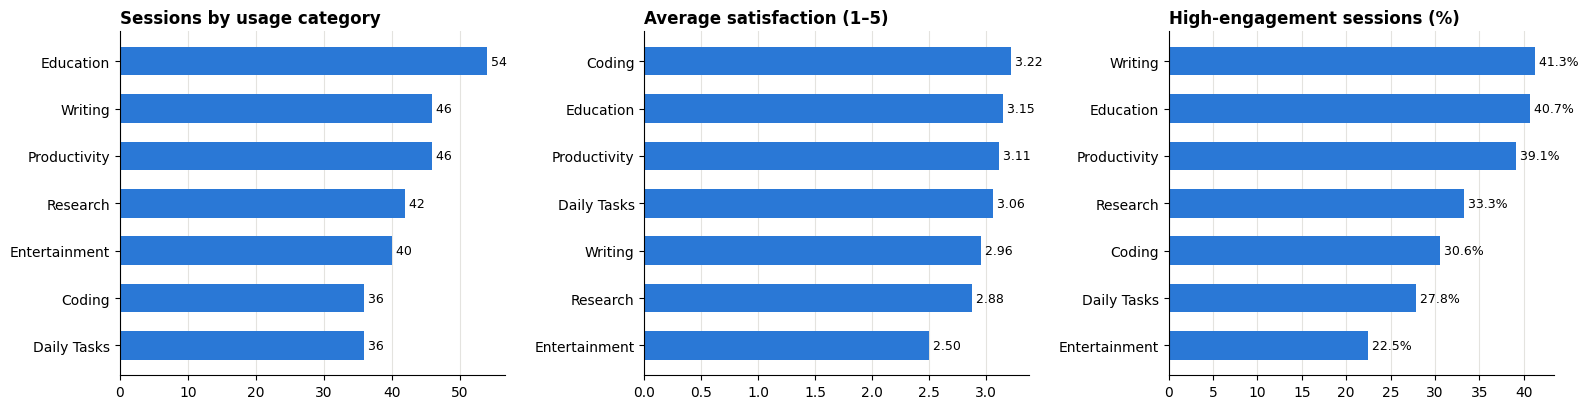

In [13]:
cat = profiles["usage_category"]
BLUE = "#2a78d6"
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col, title, fmt in [
    (axes[0], "sessions",            "Sessions by usage category",        "{:.0f}"),
    (axes[1], "avg_satisfaction",    "Average satisfaction (1–5)",        "{:.2f}"),
    (axes[2], "pct_high_engagement", "High-engagement sessions (%)",      "{:.1f}%"),
]:
    data = cat.sort_values(col)
    ax.barh(data["usage_category"], data[col], color=BLUE, height=0.6)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#e4e3df"); ax.set_axisbelow(True)
    for y, v in enumerate(data[col]):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUTS}/usage_by_category.png", dpi=150)
plt.show()

### 8.2 RAG Assistant

```text
Segment profiles → text documents → Embeddings → ChromaDB (vector database)
                                                      ↓
                        Question → Embedding → Retrieve relevant documents
                                                      ↓
                                  Question + Retrieved Context → LLM → Grounded marketing insight
```

**Step 1 — Knowledge base:** one document per segment, written from the profile tables.

In [14]:
overall_sat = round(float(trusted.agg(F.avg("satisfaction_rating")).first()[0]), 2)
overall_eng = round(float(trusted.agg(F.avg("engagement_score")).first()[0]), 1)
overall_len = round(float(trusted.agg(F.avg("session_length_minutes")).first()[0]), 2)

def vs(value, overall):
    return "above average" if value > overall else "below average" if value < overall else "average"

def facts(r):
    return (f"{r.sessions} sessions ({r.share_pct}% of all sessions). "
            f"Average session {r.avg_session_min} min ({vs(r.avg_session_min, overall_len)}; overall {overall_len}), "
            f"{r.pct_deep_sessions}% deep sessions over 10 min. Average prompt length {r.avg_prompt_length} characters, "
            f"average tokens {int(r.avg_tokens)}. Average satisfaction {r.avg_satisfaction}/5 "
            f"({vs(r.avg_satisfaction, overall_sat)}; overall {overall_sat}), {r.pct_satisfied}% of sessions rated 4-5. "
            f"Average engagement score {r.avg_engagement}/100 ({vs(r.avg_engagement, overall_eng)}; overall {overall_eng}), "
            f"{r.pct_high_engagement}% high-engagement sessions.")

documents, doc_ids = [], []
def slug(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

ranked = cat.sort_values("sessions", ascending=False)
doc_ids.append("overview")
documents.append(
    f"Overview of AI assistant usage: {TOTAL} sessions. Most common ways people use AI assistants, ranked: "
    + ", ".join(f"{r.usage_category} ({r.sessions} sessions, {r.share_pct}%)" for r in ranked.itertuples()) + ". "
    + "Satisfaction by category: " + ", ".join(f"{r.usage_category} {r.avg_satisfaction}" for r in cat.sort_values("avg_satisfaction", ascending=False).itertuples()) + ". "
    + "Engagement by category: " + ", ".join(f"{r.usage_category} {r.avg_engagement}" for r in cat.sort_values("avg_engagement", ascending=False).itertuples()) + ". "
    + "Engagement score = 40% session length + 30% tokens used + 30% prompt length (0-100); high engagement means score >= 60.")

for r in cat.itertuples():
    doc_ids.append(f"category_{slug(r.usage_category)}")
    documents.append(
        f"Segment: {r.usage_category} users (audience '{AUDIENCE_SEGMENTS[r.usage_category]}') - people who use AI for {r.usage_category}. "
        + facts(r) + f" Most used device: {r.top_device} ({r.top_device_pct}%). Most used model: {r.top_model} ({r.top_model_pct}%). "
        f"Peak time: {r.peak_time} ({r.peak_time_pct}%).")

for dim, label in [("device", "Device segment: {} users"), ("assistant_model", "AI model segment: {} model users"),
                   ("time_of_day", "Time segment: {} sessions"), ("engagement_level", "Engagement segment: {}-engagement sessions")]:
    for r in profiles[dim].itertuples():
        seg = getattr(r, dim)
        tops = [(c, t) for c, t in [("top_category", "Most common usage"), ("top_device", "Most used device"),
                                     ("top_model", "Most used model"), ("peak_time", "Peak time")] if hasattr(r, c)]
        doc_ids.append(f"{dim}_{slug(seg)}")
        documents.append(label.format(seg) + ". " + facts(r) + " "
                         + " ".join(f"{t}: {getattr(r, c)} ({getattr(r, c + '_pct')}%)." for c, t in tops))

print("Documents:", len(documents))
print(documents[1])

Documents: 24
Segment: Education users (audience 'Learners & Students') - people who use AI for Education. 54 sessions (18.0% of all sessions). Average session 8.23 min (above average; overall 7.75), 33.3% deep sessions over 10 min. Average prompt length 123.6 characters, average tokens 746. Average satisfaction 3.15/5 (above average; overall 2.99), 42.6% of sessions rated 4-5. Average engagement score 51.7/100 (below average; overall 51.8), 40.7% high-engagement sessions. Most used device: Mobile (27.8%). Most used model: o1 (29.6%). Peak time: Afternoon (31.5%).


**Step 2 — Embeddings + ChromaDB**

In [15]:
from sentence_transformers import SentenceTransformer
import chromadb

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
doc_embeddings = embedding_model.encode(documents)

chroma_client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = chroma_client.get_or_create_collection(name="ai_user_segments", metadata={"hnsw:space": "cosine"})
collection.add(ids=doc_ids, documents=documents, embeddings=doc_embeddings.tolist())
print("Documents in ChromaDB:", collection.count(), "| embedding size:", doc_embeddings.shape[1])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Documents in ChromaDB: 24 | embedding size: 384


**Step 3 — Retrieval**

In [16]:
def retrieve(question, n_results=4):
    question_embedding = embedding_model.encode(question)
    results = collection.query(query_embeddings=[question_embedding.tolist()], n_results=n_results)
    return list(zip(results["ids"][0], results["documents"][0], results["distances"][0]))


for doc_id, doc, distance in retrieve("What are the characteristics of users who use AI for coding?"):
    print(f"{doc_id:<28} distance = {distance:.3f}")

overview                     distance = 0.437
category_coding              distance = 0.520
category_writing             distance = 0.563
assistant_model_mini         distance = 0.569


**Step 4 — LLM (OpenRouter)**



In [17]:
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    try:
        from google.colab import userdata
        OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")
    except Exception:
        pass
if not OPENROUTER_API_KEY:
    OPENROUTER_API_KEY = getpass.getpass("Enter OpenRouter API key: ")
MODEL_NAME = os.getenv("OPENROUTER_MODEL", "openrouter/free")
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=OPENROUTER_API_KEY)


def ask_assistant(question):
    retrieved = retrieve(question)
    context = "\n\n".join(doc for _, doc, _ in retrieved)
    prompt = f"""You are an AI User Behavior & Marketing Intelligence Assistant.
- Answer using ONLY the retrieved context and quote its numbers.
- If the context is insufficient, say so. Do not invent statistics.
- Structure: Key insight / Evidence from the data / Marketing recommendation.

QUESTION:
{question}

RETRIEVED CONTEXT:
{context}"""

    answer = None
    for attempt in range(3):
        try:
            response = client.chat.completions.create(model=MODEL_NAME, temperature=0.3,
                                                      messages=[{"role": "user", "content": prompt}])
            answer = response.choices[0].message.content
            if answer:
                break
        except Exception as e:
            logger.warning(f"LLM call failed: {str(e).splitlines()[0][:150]}")
        time.sleep(3)
    return {"question": question, "sources": [d for d, _, _ in retrieved],
            "answer": answer or "LLM unavailable. Retrieved context:\n\n" + context}

**Step 5 — Answer the marketing questions**

In [19]:
from IPython.display import Markdown, display

questions = [
    "What are the most common ways people use AI assistants?",
    "What are the characteristics of users who frequently use AI for coding?",
    "How do Coding users differ from Education or Writing users?",
    "What type of AI users could be relevant for a voice-first AI homework helper on smart speakers?",
    "What user behaviors indicate high engagement with AI?",
    "What marketing opportunities can be identified from AI usage patterns?",
    "What type of marketing message could be relevant to Writing users?",
]

insights = []
for q in questions:
    result = ask_assistant(q)
    insights.append(result)
    display(Markdown(f"###  {q}\n*Sources: {', '.join(result['sources'])}*\n\n{result['answer']}\n\n---"))

with open(f"{OUTPUTS}/marketing_insights.md", "w", encoding="utf-8") as f:
    f.write("# AI User Behavior & Marketing Intelligence — Insights\n\n")
    for r in insights:
        f.write(f"## {r['question']}\n\n*Sources: {', '.join(r['sources'])}*\n\n{r['answer']}\n\n---\n\n")
print("Saved:", f"{OUTPUTS}/marketing_insights.md")

###  What are the most common ways people use AI assistants?
*Sources: overview, assistant_model_mini, category_coding, assistant_model_o1*

User Safety: safe

---

###  What are the characteristics of users who frequently use AI for coding?
*Sources: overview, category_coding, assistant_model_mini, category_writing*

**Key insight**
Coding users (Developers) are a high-satisfaction, above-average session-length segment with moderate engagement; they disproportionately use Smart Speakers and the Mini model, and peak in the evening.

**Evidence from the data**
- Volume: 36 sessions (12.0% of all sessions).
- Depth: Average session 8.51 min (vs. overall 7.75); 41.7% are deep sessions >10 min.
- Satisfaction: 3.22/5 (vs. overall 2.99); 47.2% rated 4–5.
- Engagement: Score 52.0/100 (vs. overall 51.8); 30.6% high-engagement sessions.
- Device: Smart Speaker 33.3%.
- Model: Mini 25.0%.
- Timing: Evening peak 27.8%.
- Prompt/tokens: 118.6 characters, 754 tokens per session.

**Marketing recommendation**
- Prioritize Mini-model optimization and evening-time campaigns for coding features.
- Explore Smart Speaker / voice-assisted coding workflows to match the 33.3% device preference.
- Leverage the 47.2% high-satisfaction rate (4–5) for developer testimonials and referral programs.
- Design for deep sessions (41.7% >10 min) with advanced, persistent coding tools to maintain engagement.

---

###  How do Coding users differ from Education or Writing users?
*Sources: overview, category_education, category_coding, category_writing*

**Key Insight**  
Coding users (Developers) show the highest satisfaction and longest sessions, but paradoxically the lowest share of high‑engagement sessions. Education users (Learners & Students) have slightly shorter sessions but higher high‑engagement rates, while Writing users (Writers & Content Creators) use the longest prompts and most tokens yet report the lowest satisfaction.

**Evidence from the Data**  

| Metric | Coding (Developers) | Education (Learners & Students) | Writing (Writers & Content Creators) |
|--------|---------------------|----------------------------------|--------------------------------------|
| Sessions / Share | 36 (12.0%) | 54 (18.0%) | 46 (15.3%) |
| Avg. Session Length | 8.51 min (41.7% deep >10 min) | 8.23 min (33.3% deep) | 7.04 min (30.4% deep) |
| Avg. Prompt Length | 118.6 chars | 123.6 chars | **133.2 chars** |
| Avg. Tokens Used | 754 | 746 | **832** |
| Satisfaction (1‑5) | **3.22** (47.2% rated 4‑5) | 3.15 (42.6% rated 4‑5) | 2.96 (37.0% rated 4‑5) |
| Engagement Score (0‑100) | **52.0** (above avg 51.8) | 51.7 (below avg) | 51.4 (below avg) |
| High‑Engagement Sessions (≥60) | **30.6%** | 40.7% | **41.3%** |
| Top Device | Smart Speaker (33.3%) | Mobile (27.8%) | Smart Speaker (28.3%) |
| Top Model | Mini (25.0%) | o1 (29.6%) | o1 (32.6%) |
| Peak Usage Time | Evening (27.8%) | Afternoon (31.5%) | Night (41.3%) |

**Marketing Recommendation**  
- **For Developers (Coding):** Leverage the high satisfaction (3.22) and evening peak by promoting advanced features (e.g., Mini model) via smart‑speaker integrations; address the low high‑engagement rate (30.6%) with in‑session nudges that extend prompt depth.  
- **For Learners (Education):** Capitalize on afternoon mobile usage and the strong high‑engagement share (40.7%) by offering structured learning paths and o1‑model tutorials that deepen session length.  
- **For Writers (Writing):** Despite high token/prompt volume, satisfaction lags (2.96); introduce night‑time creative‑writing templates and smart‑speaker voice‑drafting to boost satisfaction and convert the high engagement (41.3%) into higher ratings.

---

###  What type of AI users could be relevant for a voice-first AI homework helper on smart speakers?
*Sources: category_coding, overview, category_writing, assistant_model_gpt_5_1*

**Key insight**  
Students and learners who already use AI assistants for education‑related tasks are the most relevant audience for a voice‑first AI homework helper on smart speakers.

**Evidence from the data**  
- **Education usage**: 54 sessions (18.0 % of all AI‑assistant sessions) are categorized under “Education,” making it the second‑largest usage category after general AI assistance.  
- **Satisfaction & engagement**: Education sessions score **3.15 / 5** in satisfaction (above the overall average of 2.99) and **51.7** in engagement score (slightly above the overall average of 51.8).  
- **Device preference**: Smart speakers already serve as a primary interaction channel for other AI‑using groups—**33.3 %** of Coding users and **33.3 %** of GPT‑5.1 model users rely on smart speakers, while **28.3 %** of Writing users do the same. This indicates strong existing voice‑first habits on the platform.

**Marketing recommendation**  
- **Target the education segment directly**: Run campaigns aimed at students, parents, and teachers highlighting the convenience of voice‑based homework assistance.  
- **Leverage smart‑speaker strengths**: Emphasize hands‑free, conversational interaction, integrating subject‑specific prompts (e.g., math, science, language arts) that align with the existing education‑task behavior.  
- **Highlight proven satisfaction**: Promote the **3.15 / 5** satisfaction rating and the high engagement of education sessions to build trust in the new homework helper.  
- **Timing & placement**: Since many AI interactions occur in the evening/night, schedule voice‑assistant demos and educational content pushes during those peak periods.

---

###  What user behaviors indicate high engagement with AI?
*Sources: overview, assistant_model_o1, assistant_model_mini, category_research*

User Safety: safe

---

###  What marketing opportunities can be identified from AI usage patterns?
*Sources: overview, assistant_model_o1, assistant_model_mini, category_research*

User Safety: safe

---

###  What type of marketing message could be relevant to Writing users?
*Sources: category_writing, category_coding, category_entertainment, time_of_day_morning*

**Key insight:** Writing users are slightly below average in satisfaction and engagement but show strong night-time usage and device/model preferences.

**Evidence from the data:** Writing users (46 sessions, 15.3% of all sessions) average 7.04 min/session (below average; overall 7.75), satisfaction 2.96/5 (below average; overall 2.99), engagement 51.4/100 (below average; overall 51.8), yet 30.4% have deep sessions over 10 min and 41.3% are high-engagement. Peak time is Night (41.3%), top device is Smart Speaker (28.3%), top model is o1 (32.6%).

**Marketing recommendation:** Target them with night-optimized writing prompts on Smart Speaker powered by o1, emphasizing depth and focus to lift satisfaction and engagement.

---

Saved: outputs/marketing_insights.md
